#### Simulations Parameter 

In [1]:
import os
os.chdir("C:/Users/ajahn/hda/Abschlussarbeiten/Butt/Paper/ButtMACode/Masterarbeit_Butt/Paper_abgabe/simulation_study")

#Libarys
from utils_AJ import simulationsingle, calculate_contributions_variance
from utils import create_weibull_data
import numpy as np
from scipy.stats import spearmanr
from lifelines import KaplanMeierFitter, WeibullAFTFitter
from sksurv.util import Surv
from sklearn.model_selection import train_test_split
from class_DecisionTreeBaggingClassifier import DecisionTreeBaggingClassifier
import sksurv as sksurv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
import json
import warnings
warnings.filterwarnings("ignore", message="findfont: Font family")


In [2]:
# data generation parameters and RF parameters

X_pred_point = pd.DataFrame({'X_1': [1], 'X_2': [1], 'X_3': [80], 'X_4': [40]})

data_generation_parameter =   { 'shape_weibull': 1,  'p_1': -0.405, 'p_2': -0.4, 'p_3': -0.05, 'p_4': -0.01, 
                                        'tau': 37, 
                                        'X_pred_point': X_pred_point}  
         

params_rf =         {       'max_depth':4,
                            'min_samples_split':5,
                            'max_features': 'log2',
                            'weighted_bootstrapping': True, }          
                            

                            

In [3]:

seed_base = 40
n = 1000
B = 1000


#10% cens
#scale_weibull_base = 22080
#rate_censoring = 0.00312

#30% cens
#scale_weibull_base = 18900
#rate_censoring = 0.01125

#50% cens
#scale_weibull_base = 15120
#rate_censoring = 0.023293

#10% cens
#scale_weibull_base = 8951
#rate_censoring = 0.00378

#30% cens
#scale_weibull_base = 7100
#rate_censoring = 0.0142

#50% 
scale_weibull_base = 4665
rate_censoring = 0.0355


params_rf_loop = params_rf.copy()
params_rf_loop["n_estimators"] = B
params_rf_loop["random_state"] = seed_base  # wichtig für Reproduzierbarkeit

dp_loop = data_generation_parameter.copy()
dp_loop["scale_weibull_base"] = scale_weibull_base
dp_loop["rate_censoring"] = rate_censoring
dp_loop["n"] = n


result = simulationsingle(
    seed=seed_base,
    data_generation_parameter=dp_loop,
    params_rf=params_rf_loop
)


(
    B,
    n,
    n_plus,
    weights,
    cov_i,
    cov_i_wager,
    array,
    hatV,
    sumw,
    df_train

) = result




array([0.00030767, 0.00014507, 0.00015863, 0.00030307, 0.00020551,
       0.00010007, 0.00011215, 0.0003055 , 0.00018746, 0.00035528,
       0.00012655, 0.00074915, 0.00011251, 0.00010682, 0.00016363,
       0.00012158, 0.00012325, 0.00013084, 0.00013561, 0.0003717 ,
       0.00010202, 0.00042385, 0.0001269 , 0.00018593, 0.00048043,
       0.00024249, 0.00097116, 0.00013493, 0.00039547, 0.00010763,
       0.00023369, 0.00017702, 0.00110203, 0.00086821, 0.00016395,
       0.00066216, 0.00018637, 0.00014606, 0.0002989 , 0.00062911,
       0.00010954, 0.00011867, 0.00045373, 0.00012218, 0.0001545 ,
       0.0001769 , 0.00074936, 0.0001095 , 0.0001193 , 0.00021749,
       0.00047561, 0.00010586, 0.00017401])

array([0.00666737, 0.00570058, 0.00155662, 0.00666737, 0.00343892,
       0.00174532, 0.00196042, 0.00666737, 0.00588447, 0.00374812,
       0.00351056, 0.00666737, 0.00666737, 0.00666737, 0.00666737,
       0.00220163, 0.00188929, 0.00666737, 0.00351056, 0.00570058,
       0.00170393, 0.00666737, 0.00653915, 0.00666737, 0.00666737,
       0.00666737, 0.00570058, 0.00666737, 0.00666737, 0.00666737,
       0.0049191 , 0.00174178, 0.00666737, 0.00666737, 0.00666737,
       0.00666737, 0.00144096, 0.00666737, 0.00666737, 0.00666737,
       0.00666737, 0.00374812, 0.00666737, 0.00459412, 0.00261588,
       0.00666737, 0.00666737, 0.00238283, 0.00243817, 0.00666737,
       0.00666737, 0.00172088, 0.00666737])

,X_1,X_2,X_3,X_4,event,time,survived,weights_ipcw
14,0,0,80.473272,39.742278,False,51.850595,1,0.006667
20,0,1,82.740706,38.730090,True,35.037534,0,0.005701
40,1,0,83.584371,42.780231,True,2.421050,0,0.001557
53,0,1,68.200088,35.827539,False,45.204258,1,0.006667
61,0,1,74.709723,38.373821,True,24.540546,0,0.003439
73,1,1,82.153361,36.380409,True,5.153583,0,0.001745
94,0,1,86.095916,44.120103,True,8.165906,0,0.001960
103,0,1,84.325751,36.078010,True,39.804456,1,0.006667
127,0,1,79.431047,36.469564,True,35.727877,0,0.005884
144,0,0,82.351841,36.966143,True,25.987375,0,0.003748


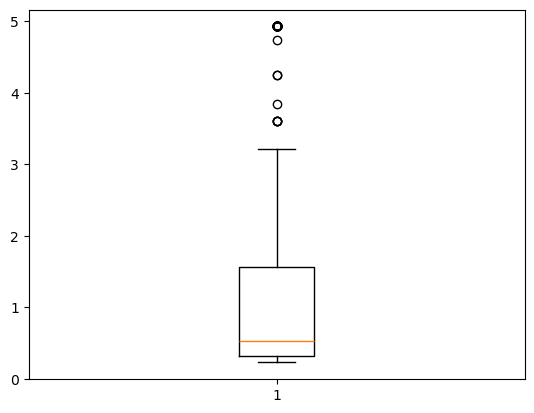

Anzahl an Boostrap-Wiederholungen


1000

Größe der Trainingsstichprobe


700

Anzahl an Beobachtungen mit positivem Gewicht


...

Varianz von Wager


0.009359803573054073

korrigierte Varianz


0.0037208378131443204

cov_i


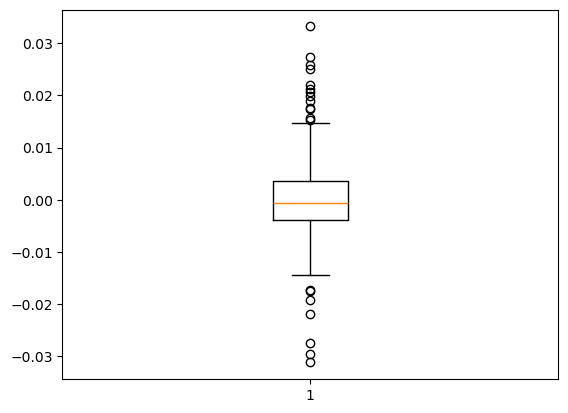

cov_i^2 gegen korrigierte terme


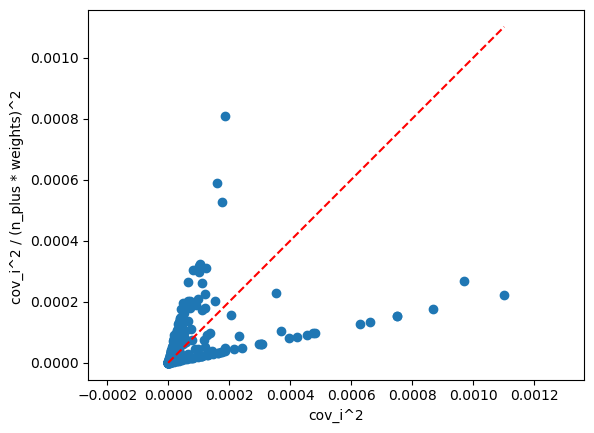

cov_i gegen Gewichte w_i


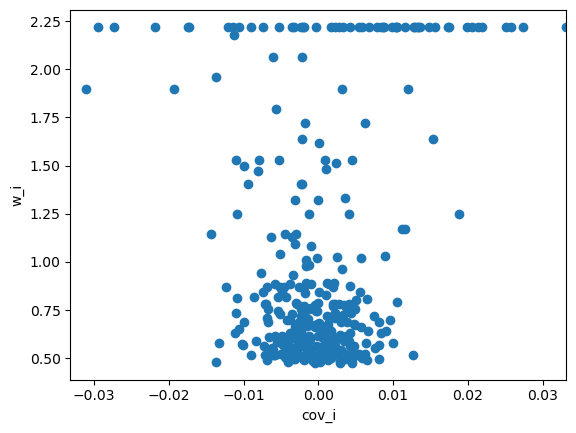

cov_i^2 gegen Gewichte w_i^2


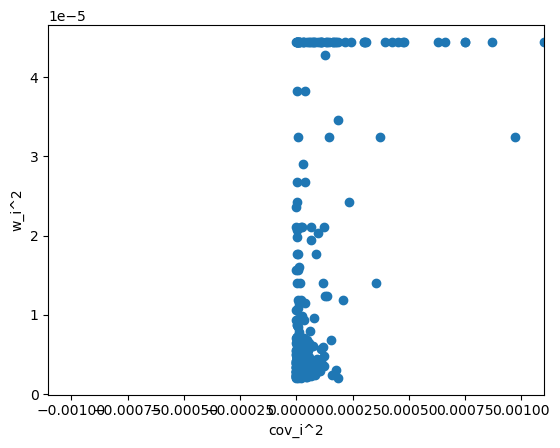

cov_i^2 gegen (1/n_plus*w_i)^2


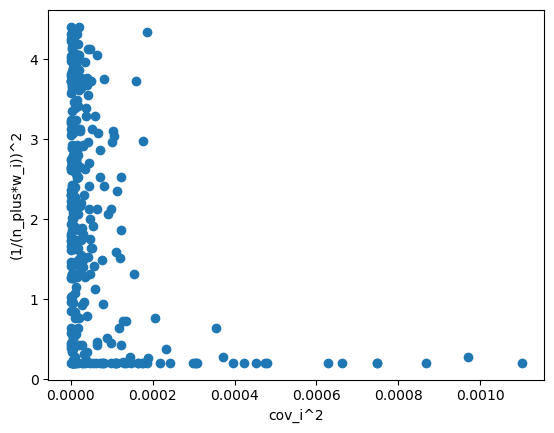

In [4]:
import matplotlib.pyplot as plt


display(np.asarray(cov_i**2).reshape(-1)[np.asarray(cov_i**2).ravel() > 0.0001])
display(np.asarray(weights).reshape(-1)[np.asarray(cov_i**2).ravel() > 0.0001])
display(df_train[np.asarray(cov_i**2).ravel() > 0.0001],)


plt.boxplot((weights[weights != 0]*n_plus)**2)
plt.show()

print("Anzahl an Boostrap-Wiederholungen")
display(B)

print("Größe der Trainingsstichprobe")
display(n)

print("Anzahl an Beobachtungen mit positivem Gewicht")
display(int(n_plus))

print("base learner variability (V(T(x,N*))")
display(hatV.item())

print("Summe der (1-w_i)/w_i")
display(float(sumw))

print("unkorrigierter Varianzterm von Wager: Summe der cov_i^2")
display(float(np.sum(cov_i**2)))

print("korrigierter Varianzterm von Wager")
display(float(1/n_plus ** 2 * np.sum(np.asarray(cov_i).reshape(-1)[weights != 0]**2 / np.asarray(weights).reshape(-1)[weights != 0]**2)))

print("approximative Veränderung des Varianzterms von Wager: 1/n+^3 * Summe der (1/w_i**2)")
display(float(1/(n_plus**3) * np.sum(1 / weights[weights != 0]**2)))

print("Bias-Korrekturterm Wager: n/B * V(T(x,N*)")
display((n/B*hatV).item())

print("%-ale Veränderung des Bias-Korrekturterms von Wager: 1/n+^2 * Summe der (1-w_i)/w_i - 1")
display(float(1/(n_plus**2) * sumw -1))

print("Varianz von Wager")
display(float(np.sum((cov_i**2)))-(n/B*hatV).item())
#display(float(np.sum((cov_i**2)[cov_i**2 < 0.0125]))-(n/B*hatV).item())

print("korrigierte Varianz")
display(float(1/n_plus ** 2 * np.sum((np.asarray(cov_i).reshape(-1))[(weights != 0)]**2 / np.asarray(weights).reshape(-1)[weights != 0]**2)-1/(n_plus**2)*(n/B*hatV).item()*sumw))


print("cov_i")
plt.boxplot((cov_i[weights != 0]))
plt.show()

print("cov_i^2 gegen korrigierte terme")
w = np.asarray(weights).reshape(-1)
c = np.asarray(cov_i).reshape(-1)
x = c ** 2
y = 1 / ( (n_plus * w) ** 2) * c ** 2  

min_val = min(np.min(x), np.min(y))
max_val = max(np.max(x), np.max(y))

plt.scatter(x, y)
plt.xlabel("cov_i^2")
plt.ylabel("cov_i^2 / (n_plus * weights)^2 ")
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.axis('equal')
plt.show()


print("cov_i gegen Gewichte w_i")
w = np.asarray(weights).reshape(-1)[np.asarray(weights).ravel() != 0]
c = np.asarray(cov_i).reshape(-1)[np.asarray(weights).ravel() != 0]
x = c 
y = w*n_plus 

m = np.max(np.abs(x))
plt.scatter(x, y)
plt.xlabel("cov_i")
plt.ylabel("w_i")
plt.xlim(-m, m)
plt.show()


print("cov_i^2 gegen Gewichte w_i^2")
w = np.asarray(weights).reshape(-1)[np.asarray(weights).ravel() != 0]
c = np.asarray(cov_i).reshape(-1)[np.asarray(weights).ravel() != 0]
x = c**2 
y = w**2 

m = np.max(np.abs(x))
plt.scatter(x, y)
plt.xlabel("cov_i^2")
plt.ylabel("w_i^2")
plt.xlim(-m, m)
plt.show()

print("cov_i^2 gegen (1/n_plus*w_i)^2")
w = np.asarray(weights).reshape(-1)[np.asarray(weights).ravel() != 0]
c = np.asarray(cov_i).reshape(-1)[np.asarray(weights).ravel() != 0]
x = c ** 2
y = (1/(n_plus * w)) ** 2

plt.scatter(x, y)
plt.xlabel("cov_i^2")
plt.ylabel("(1/(n_plus*w_i))^2")
plt.show()

In [ ]:
results_list1 = []
results_list2 = []


seed_base = np.random.randint(0, 1_000_000)
n = 10000
B = 2000

n_scale = [22_080, 18_900, 15120, 8_951, 7_100, 4665]
n_rate = [0.00321,  0.01125, 0.023293, 0.00378, 0.0142, 0.0355]
        
for i, scale_weibull_base in enumerate(n_scale):
        rate_censoring = n_rate[i]

        seed = seed_base + i * 1000 

        params_rf_loop = params_rf.copy()
        params_rf_loop["n_estimators"] = B
        params_rf_loop["random_state"] = seed  

        dp_loop = data_generation_parameter.copy()
        dp_loop["scale_weibull_base"] = scale_weibull_base
        dp_loop["rate_censoring"] = rate_censoring
        dp_loop["n"] = n
    
        
        result = simulationAJ(
            seed=seed,
            data_generation_parameter=dp_loop,
            params_rf=params_rf_loop
        )

        (
            B_out,
            n_out,
            n_plus,
            weights,
            cov_i,
            cov_i_wager,
            array,
            hatV,
            sumw,
            train_df
        ) = result

        results_list1.append({
            "n": n_out,
            "B": B_out,
            "n_plus": n_plus,
            "hatV": hatV,
            "sumw": sumw,
            "uV_Wager": np.sum(cov_i**2),
            "uV_jahnbutt": np.sum((np.asarray(cov_i).reshape(-1)[np.asarray(weights).reshape(-1) != 0] / (n_plus * np.asarray(weights).reshape(-1)[np.asarray(weights).reshape(-1) != 0]))**2),
            "c_uV": float(1/(n_plus**3) * np.sum(1 / weights[weights != 0]**2) -1),
            "bk_wager": (n_out/B_out*hatV).item(),
            "bk_jahnbutt": (n_out/B_out * hatV).item() * sumw / n_plus**2,
            "c_bk": float(1/(n_plus**2) * sumw -1),
            "V_Wager": np.sum(cov_i**2)-(n_out/B_out*hatV).item(),
            "V_wir": np.sum((np.asarray(cov_i).reshape(-1)[np.asarray(weights).reshape(-1) != 0] / (n_plus * np.asarray(weights).reshape(-1)[np.asarray(weights).reshape(-1) != 0]))**2) - (n_out/B_out * hatV).item() * sumw / n_plus**2
        })


        results_list2.append({
            "n": n_out,
            "B": B_out,
            "n_plus": n_plus,
            "meancov": float(np.mean(cov_i[weights!=0])),
            "sdcov": float(np.std(cov_i[weights!=0])),
            "VCcov": float(np.std(cov_i[weights!=0])/np.mean(cov_i[weights!=0])),
            "corr": np.corrcoef(np.asarray(weights**2).ravel()[np.asarray(weights).ravel() != 0], np.asarray(cov_i**2).ravel()[np.asarray(weights).ravel() != 0])[0,1],
            "spcorr": spearmanr(np.asarray(weights**2).ravel()[np.asarray(weights).ravel()!=0], np.asarray(cov_i**2).ravel()[np.asarray(weights).ravel()!=0])[0],
            "meddevcov": float(np.median(np.abs(cov_i[weights!=0] - np.median(cov_i[weights!=0])))),
            "madscore": float(np.max(np.abs(cov_i[weights!=0] - np.median(cov_i[weights!=0]))) / np.median(np.abs(cov_i[weights!=0] - np.median(cov_i[weights!=0]))))
        })



In [ ]:

df_results = pd.DataFrame(results_list1)
display(df_results)

df_results = pd.DataFrame(results_list2)
display(df_results)
  